In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.dataset as ds
import re
from pathlib import Path
from collections import Counter
import matplotlib.gridspec as gridspec

# Cấu hình màu sắc thống nhất
SPAM_COLOR = '#E24B4A'
HAM_COLOR  = '#1D9E75'

# Cấu hình hiển thị
pd.set_option('display.max_colwidth', 500)
plt.style.use('seaborn-v0_8-whitegrid')

In [9]:
# Xác định đường dẫn (Giả sử notebook nằm ở thư mục notebooks/)
BRONZE_DIR = Path("../data/bronze")

# Load toàn bộ dữ liệu từ Bronze
print("Đang tải dữ liệu từ Bronze...")
df_bronze = pd.read_parquet(BRONZE_DIR)

# 1. Định nghĩa danh sách tháng chính xác (2025-05 -> 2026-03)
months_2025 = [f"2025-{str(m).zfill(2)}" for m in range(5, 13)]
months_2026 = [f"2026-{str(m).zfill(2)}" for m in range(1, 4)]
initial_months = months_2025 + months_2026


dataset = ds.dataset(BRONZE_DIR, format="parquet", partitioning="hive")

# 3. Filter ngay khi load để tiết kiệm RAM
df = dataset.to_table(
    filter=ds.field("month_partition").isin(initial_months)
).to_pandas()

# 4. Xử lý ép kiểu chuỗi (y hệt logic trong TextCleaner của bạn)
# Chuyển sang string trước rồi mới fillna vì NaN trong pandas đôi khi là float
df['body_str'] = df['body'].astype(str).replace("nan", "") 

df = df_bronze[df_bronze['month_partition'].isin(initial_months)].copy()

# Xử lý NaN tạm thời để tránh lỗi các hàm xử lý chuỗi
df['body_str'] = df['body'].astype(str).fillna("")

print(f"Tổng số dòng phân tích: {len(df):,}")
print(f"Các tháng: {df['month_partition'].unique()}")
display(df.head(3))

Đang tải dữ liệu từ Bronze...
Tổng số dòng phân tích: 110,000
Các tháng: ['2025-05', '2025-06', '2025-07', '2025-08', '2025-09', ..., '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
Length: 11
Categories (11, object): ['2025-05', '2025-06', '2025-07', '2025-08', ..., '2025-12', '2026-01', '2026-02', '2026-03']


,email_id,body,label,raw_label,received_at,month_partition,body_str
0,email_202505_00000,viiiiiiagraaaa\nonly for the ones that want to make her scream .\nprodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend miscellany chalkboard whizzing pend armenian cutlet waring makeshift fletch dispel crest cadet dovetail rapprochement gerry bayreuth selectman wilmington tuttle alchemy itt bullyboy .\ncaan ' t do . . .\n,1,Spam,2025-05-03 08:02:00,2025-05,viiiiiiagraaaa\nonly for the ones that want to make her scream .\nprodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend miscellany chalkboard whizzing pend armenian cutlet waring makeshift fletch dispel crest cadet dovetail rapprochement gerry bayreuth selectman wilmington tuttle alchemy itt bullyboy .\ncaan ' t do . . .\n
1,email_202505_00001,got ice thought look az original message ice operations mailto iceoperations intcx com sent friday october escapenumber escapenumber escapenumber escapenumber pm subject escapelong amended participant agreement dear participant receiving email identified company user administrator legal counsel signatory escapelong participant agreement serves notice intercontinentals intent amend agreement effective december escapenumber escapenumber relevant documentation attached includes contact informat...,0,Ham,2025-05-22 05:43:00,2025-05,got ice thought look az original message ice operations mailto iceoperations intcx com sent friday october escapenumber escapenumber escapenumber escapenumber pm subject escapelong amended participant agreement dear participant receiving email identified company user administrator legal counsel signatory escapelong participant agreement serves notice intercontinentals intent amend agreement effective december escapenumber escapenumber relevant documentation attached includes contact informat...
2,email_202505_00002,yo ur wom an ne eds an escapenumber in ch ma n b e th at ma n f or h er le arn h ow here tu rn of f not ific ati ons here escapelong dy international exports ltd st regina escapenumber belize city belize escapelong,1,Spam,2025-05-19 12:12:00,2025-05,yo ur wom an ne eds an escapenumber in ch ma n b e th at ma n f or h er le arn h ow here tu rn of f not ific ati ons here escapelong dy international exports ltd st regina escapenumber belize city belize escapelong


### Kiểm tra phân phối nhãn

C:\Users\Admin\AppData\Local\Temp\ipykernel_16620\2532075193.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  label_dist = df.groupby(['month_partition', 'raw_label']).size().unstack()


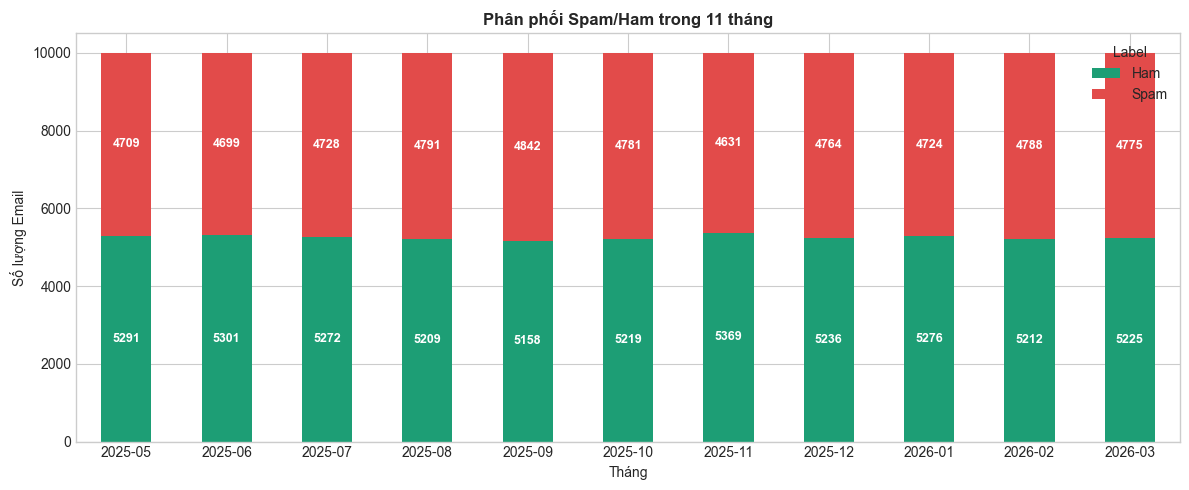

In [11]:
# Thống kê theo tháng và nhãn
label_dist = df.groupby(['month_partition', 'raw_label']).size().unstack()

# Sắp xếp lại cột để hiện Ham trước, Spam sau cho đúng màu
if 'ham' in label_dist.columns and 'spam' in label_dist.columns:
    label_dist = label_dist[['ham', 'spam']]

ax = label_dist.plot(kind='bar', stacked=True, figsize=(12, 5), color=[HAM_COLOR, SPAM_COLOR])
plt.title('Phân phối Spam/Ham trong 11 tháng', fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Số lượng Email')
plt.xticks(rotation=0)
plt.legend(title='Label')

# Thêm Label số lượng lên biểu đồ
for c in ax.containers:
    labels = [f"{v.get_height():.0f}" if v.get_height() > 0 else "" for v in c]
    ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

Nhãn tương đối cân bằng qua từng tháng, không cần xử lý thêm

### 2. Word Frequency trên RAW
Ở đây chúng ta tokenize văn bản đơn giản theo khoảng trắng để kiểm tra "rác" trong tập dữ liệu.

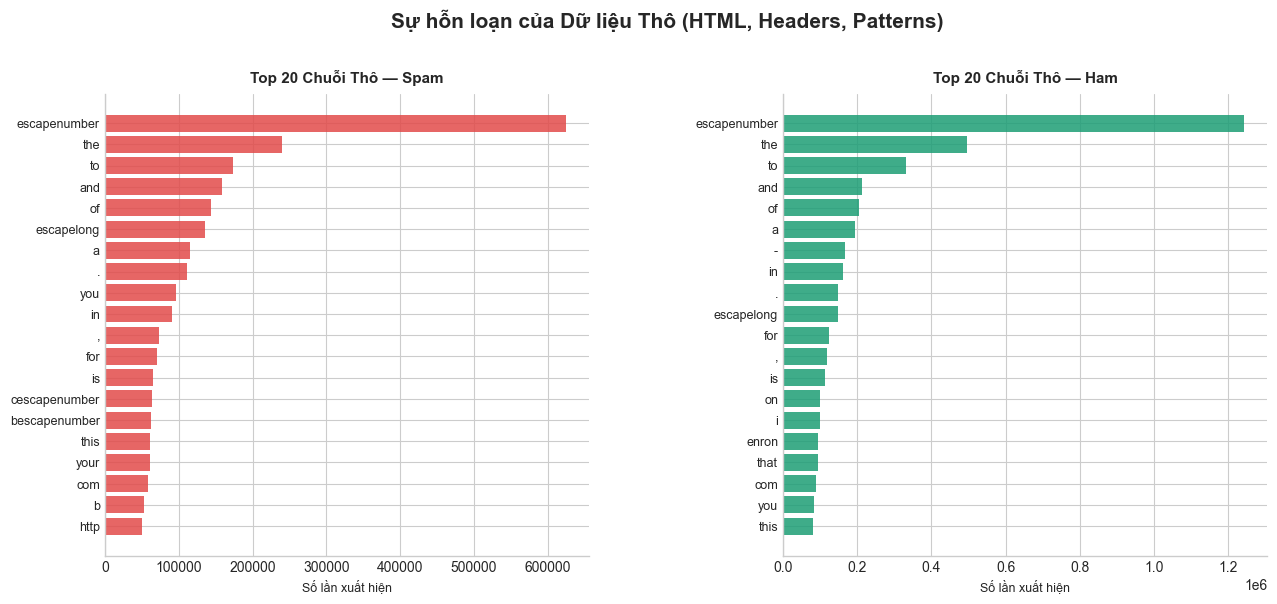

In [12]:
# Tách tập Spam và Ham
spam_raw = df[df['label'] == 1]['body_str']
ham_raw  = df[df['label'] == 0]['body_str']

def get_raw_word_freq(series, top_n=20):
    # Cắt bằng khoảng trắng
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(top_n)

spam_freq = get_raw_word_freq(spam_raw)
ham_freq  = get_raw_word_freq(ham_raw)

def plot_bar(ax, word_freq, title, color):
    words  = [str(w) for w, _ in word_freq] # Ép kiểu chuỗi để tránh lỗi hiển thị
    counts = [c for _, c in word_freq]
    ax.barh(words[::-1], counts[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Số lần xuất hiện', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(15, 6))
fig.suptitle('Sự hỗn loạn của Dữ liệu Thô (HTML, Headers, Patterns)', fontsize=15, fontweight='bold', y=1.02)
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.4)

ax1 = fig.add_subplot(gs[0, 0])
plot_bar(ax1, spam_freq, 'Top 20 Chuỗi Thô — Spam', SPAM_COLOR)

ax2 = fig.add_subplot(gs[0, 1])
plot_bar(ax2, ham_freq,  'Top 20 Chuỗi Thô — Ham',  HAM_COLOR)

plt.show()

#### Kết luận Word Frequency Analysis trên Raw

1. Thêm vào custom stopwords:
   - Các ký tự đơn lẻ: `b`, `e`, `u`, `c`, `r`, `k`, `z` — noise

2. Phát hiện các biến thể obfuscation:
   - Pattern `[a-z]escapenumber` (`cescapenumber`, `bescapenumber`...): spam dùng ký tự đặc biệt để obfuscate từ ngữ.
   - Có thể dùng regex filter normalize.


### 5. Khám phá Noise & Anonymization (Biến thể của Escapenumber)

Tỷ lệ (%) Email chứa 'escapenumber':


,has_escapenumber
raw_label,
Ham,72.92
Spam,64.13



Top 10 biến thể (Noise) của escapenumber:


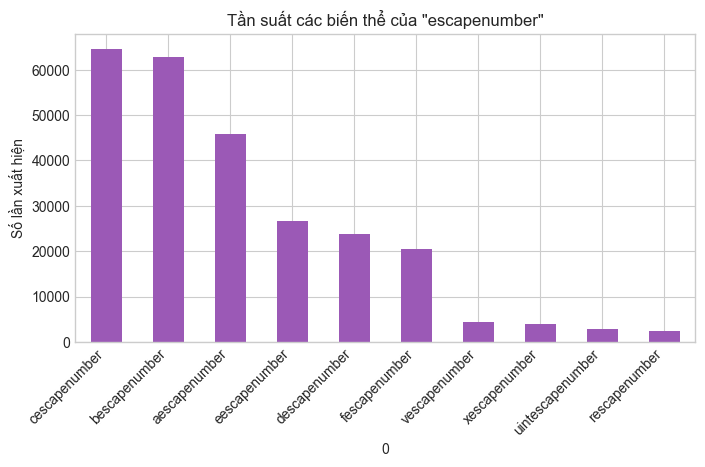

In [13]:
# Đếm số lượng email chứa token ẩn danh
df['has_escapenumber'] = df['body_str'].str.contains(r'escapenumber', flags=re.IGNORECASE)

print("Tỷ lệ (%) Email chứa 'escapenumber':")
display((df.groupby('raw_label')['has_escapenumber'].mean() * 100).round(2).to_frame())

# Tìm các biến thể (Regex bắt các chữ cái dính liền với escapenumber)
variants = df['body_str'].str.extractall(r'\b([a-z]{1,4}escapenumber)\b')[0].value_counts().head(10)

print("\nTop 10 biến thể (Noise) của escapenumber:")
plt.figure(figsize=(8, 4))
variants.plot(kind='bar', color='#9b59b6')
plt.title('Tần suất các biến thể của "escapenumber"')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Số lần xuất hiện')
plt.show()

- Xác nhận lại việc cần sử dụng regex filter

### 6. Kiểm tra tỉ lệ email có HTML / URL / Headers

In [14]:
print("% email có HTML tags:", df['body_str'].str.contains(r'<[^>]+>').mean())
print("% email có URL:",       df['body_str'].str.contains(r'https?://|www\.').mean())
print("% email có From: header:", df['body_str'].str.contains(r'^From:', re.MULTILINE).mean())
print("% email có Subject: header:", df['body_str'].str.contains(r'^Subject:', re.MULTILINE).mean())

% email có HTML tags: 0.0
% email có URL: 0.0
% email có From: header: 0.0
% email có Subject: header: 0.0


Dataset này là plain text hoàn toàn — không có HTML, không có URL, không có email headers.

### 7. kiểm tra độ dài email (char_count distribution)

In [15]:
char_counts = df['body_str'].str.len()
print(char_counts.describe())
print("% email < 20 chars:", (char_counts < 20).mean())
print("% email < 50 chars:", (char_counts < 50).mean())

count    1.100000e+05
mean     1.861745e+03
std      3.509154e+04
min      1.000000e+00
25%      3.610000e+02
50%      7.970000e+02
75%      1.807000e+03
max      1.151031e+07
Name: body_str, dtype: float64
% email < 20 chars: 0.006263636363636364
% email < 50 chars: 0.0225


- Tỷ lệ email cực ngắn (< 20 ký tự) chỉ chiếm ~0.6%, trong khi email < 50 ký tự chiếm ~2.17%.

-> Loại bỏ các email < 50 ký tự